**Student Name:** Noah Pham

**BlazerID:** tpham6

**Class:** EE 658/758 Machine Learning in Engineering


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# Preprocessing


In [2]:
df: pd.DataFrame = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X: pd.DataFrame = df.drop("Outcome", axis=1)
y: pd.Series = df["Outcome"]

print("Distribution of Target Variable:")
print(y.value_counts())

Distribution of Target Variable:
Outcome
0    500
1    268
Name: count, dtype: int64


In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Logistic Regression


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [6]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Confusion Matrix:", confusion_matrix(y_test, y_pred), sep="\n")
print("Classification Report:", classification_report(y_test, y_pred), sep="\n")

Confusion Matrix:
[[82 18]
 [26 28]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



# Neural Networks


In [7]:
clf = MLPClassifier(
    hidden_layer_sizes=(16, 16, 8),
    max_iter=1000,
    random_state=RANDOM_STATE,
    learning_rate="adaptive",
    early_stopping=True,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Confusion Matrix:", confusion_matrix(y_test, y_pred), sep="\n")
print("Classification Report:", classification_report(y_test, y_pred), sep="\n")

Confusion Matrix:
[[93  7]
 [40 14]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.93      0.80       100
           1       0.67      0.26      0.37        54

    accuracy                           0.69       154
   macro avg       0.68      0.59      0.59       154
weighted avg       0.69      0.69      0.65       154



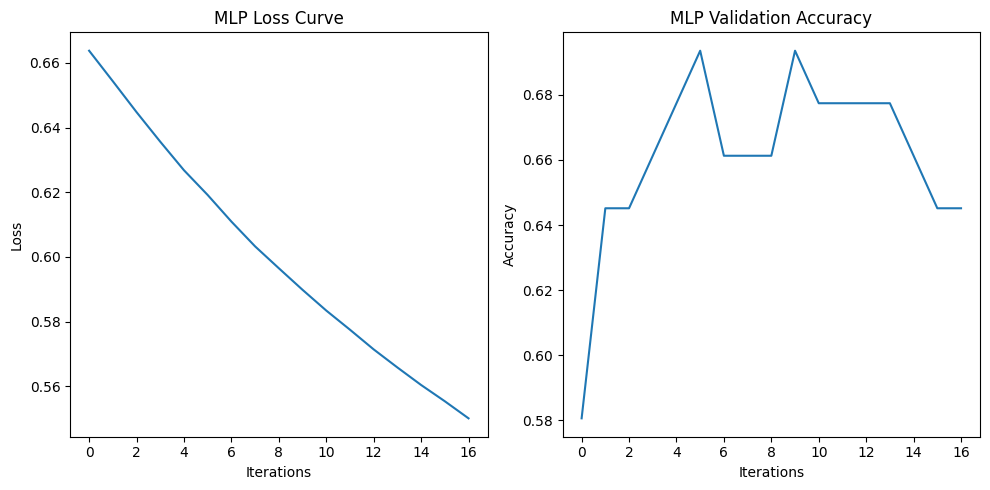

In [8]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(clf.loss_curve_)
plt.title("MLP Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(clf.validation_scores_)
plt.title("MLP Validation Accuracy")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# Dimensionality Reduction


In [9]:
def plot_correlation_heatmap(arr) -> None:
    plt.figure(figsize=(10, 5))
    sns.heatmap(
        pd.DataFrame(arr).corr(), annot=True, cmap="viridis", vmin=-1, fmt=".2f"
    )


def apply_pca(X: pd.DataFrame, n_components: int):
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)
    return X_pca

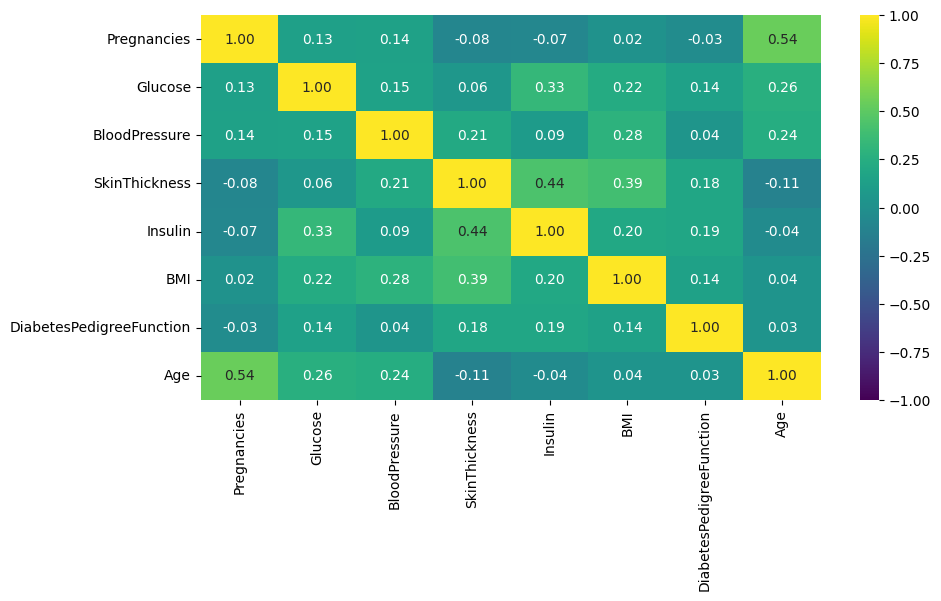

In [10]:
plot_correlation_heatmap(df.drop("Outcome", axis=1))

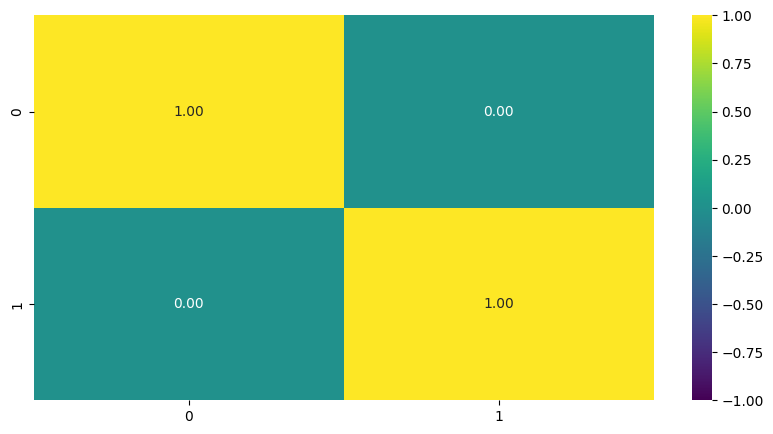

In [11]:
X_pca = apply_pca(X, 2)
plot_correlation_heatmap(X_pca)

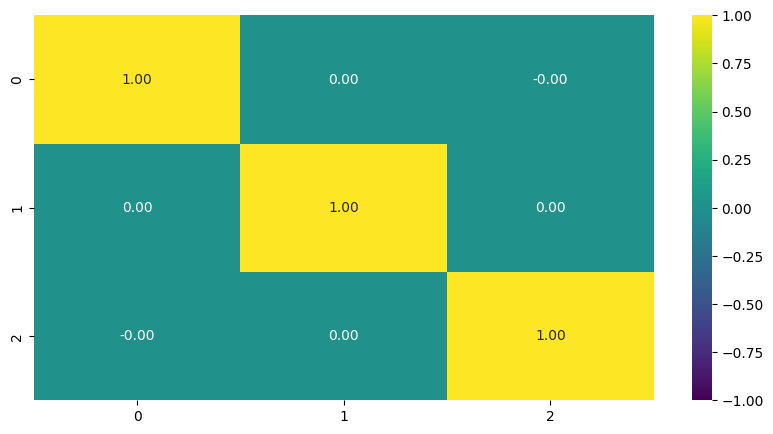

In [12]:
X_pca = apply_pca(X, 3)
plot_correlation_heatmap(X_pca)

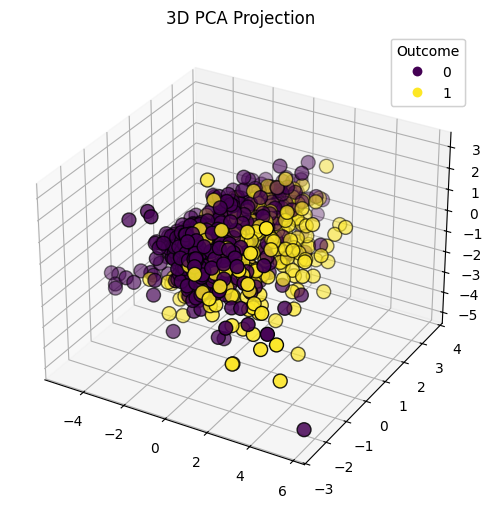

In [13]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=y,
    cmap="viridis",
    edgecolor="k",
    s=100,
)
ax.set_title("3D PCA Projection")
legend1 = ax.legend(*scatter.legend_elements(), title="Outcome")
ax.add_artist(legend1)
plt.show()

# K-Means Clustering


In [14]:
def apply_kmeans(x: pd.DataFrame) -> pd.Series:
    kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, max_iter=1000)
    kmeans.fit(x)

    return pd.Series(kmeans.labels_)

In [15]:
print("KMeans Cluster on Original Data:", apply_kmeans(X).value_counts(), sep="\n")
print("---")
print(
    "KMeans Cluster on PCA-Reduced Data:", apply_kmeans(X_pca).value_counts(), sep="\n"
)
print("---")
print("Actual Target Distribution:", y.value_counts(), sep="\n")

KMeans Cluster on Original Data:
1    464
0    304
Name: count, dtype: int64
---
KMeans Cluster on PCA-Reduced Data:
1    454
0    314
Name: count, dtype: int64
---
Actual Target Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
